# Benchmark: Penalty -> Log-Barrier 3D Solver

Tests `iterative_3d_barrier` on the same fields used by
`benchmark-3d-correction.ipynb` (synthetic random DVFs + downsampled
real Elastix volume at `DOWNSAMPLE_FACTOR = 1/4`). Reports neg-Jdet,
min Jdet, L2 distortion, and wall time per case. The existing
`iterative_3d` SLSQP path is not invoked or modified here.

## Table of Contents

1. [Configuration](#Configuration)
2. [Synthetic test fields](#Synthetic-test-fields)
3. [Run barrier solver on synthetic cases](#Run-barrier-solver-on-synthetic-cases)
4. [Real volume - CPU at multiple downsample factors](#Real-volume---CPU-at-multiple-downsample-factors)


In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

# benchmark_utils.py lives in benchmarks/ (two levels up from this notebook)
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

from benchmark_utils import (
    get_output_dir,
    log_run_footer,
    log_run_header,
    reset_figure_counter,
    results_to_rows,
    save_results_csv,
    save_summary_json,
    show_and_save,
)

from dvfopt import (
    generate_random_dvf_3d,
    jacobian_det3D,
    scale_dvf_3d,
)
from dvfopt.core.barrier.jdet3d import iterative_3d_barrier
from dvfopt.viz import (
    plot_grid_before_after,
    plot_jdet_3d_before_after,
    plot_jdet_slices,
    plot_neg_voxels_before_after,
)

In [2]:
METHOD = "barrier"
NOTEBOOK_NAME = "3d-correction"
OUTPUT_DIR = get_output_dir(METHOD, NOTEBOOK_NAME, base="../../output")
reset_figure_counter()
summary = log_run_header(METHOD, NOTEBOOK_NAME, OUTPUT_DIR)

def visualize_result(label, r, output_dir=OUTPUT_DIR, max_slices=8):
    """Render the full viz stack for a single result entry."""
    if r["n_neg_init"] == 0:
        return
    plot_neg_voxels_before_after(r["jac_init"], r["jac_final"],
                                 title=f"Negative-Jdet Voxels {label}")
    show_and_save(output_dir)
    plot_jdet_3d_before_after(r["jac_init"], r["jac_final"],
                              title=f"3D Jdet Scatter {label}")
    show_and_save(output_dir)
    plot_jdet_slices(r["jac_init"], r["jac_final"],
                     title=f"Z-Slice Jdet Heatmaps {label}",
                     max_slices=max_slices)
    show_and_save(output_dir)
    # Per-slice 2D grid on the z-slice with the most negatives
    jac_init = r["jac_init"]
    neg_per_z = (jac_init <= 0).sum(axis=(1, 2))
    z = int(np.argmax(neg_per_z))
    phi_init_2d = np.stack([r["phi_init"][1, z], r["phi_init"][2, z]])
    phi_corr_2d = np.stack([r["phi"][1, z],     r["phi"][2, z]])
    deformation_i = np.zeros((3, 1, *phi_init_2d.shape[-2:]))
    deformation_i[1, 0] = phi_init_2d[0]
    deformation_i[2, 0] = phi_init_2d[1]
    plot_grid_before_after(deformation_i, phi_corr_2d, figsize=(14, 6),
                           jac_init_override=r["jac_init"][z],
                           jac_corr_override=r["jac_final"][z])
    plt.suptitle(f"{label}  (z={z}, neg in slice={int(neg_per_z[z])})",
                 fontsize=12)
    show_and_save(output_dir)


  Benchmark  : 3d-correction
  Method     : barrier
  Timestamp  : 2026-04-16T00:05:36
  Output dir : ..\..\output\barrier\3d-correction


## Configuration

Mirrors `benchmark-3d-correction.ipynb`.


In [ ]:
SYNTHETIC_SIZES = [
    (5, 5, 5),
    (4, 6, 5),
    (6, 8, 8),
    (8, 8, 8),
]
BASE_SHAPE = (3, 3, 3, 3)
MAX_MAGNITUDE = 4.0
SEED = 42
DOWNSAMPLE_FACTORS = [1 / 4, 1 / 2]  # quarter, half
FULL_VOLUME_PATH = "../../../data/corrected_correspondences_count_touching/registered_output/deformation3d.npy"

results = {}


## Synthetic test fields

In [4]:
base_dvf = generate_random_dvf_3d(BASE_SHAPE, MAX_MAGNITUDE, SEED)
test_fields = {}
for size in SYNTHETIC_SIZES:
    dvf = scale_dvf_3d(base_dvf, size)
    jac = jacobian_det3D(dvf)
    label = f"{size[0]}x{size[1]}x{size[2]}"
    test_fields[label] = dvf
    print(f"  {label:>10s}  neg={int((jac<=0).sum()):>4d}  min_jdet={jac.min():+.4f}")

       5x5x5  neg=  64  min_jdet=-56.0061
       4x6x5  neg=  59  min_jdet=-57.0625
       6x8x8  neg= 177  min_jdet=-44.9554
       8x8x8  neg= 244  min_jdet=-43.2706


## Run barrier solver on synthetic cases

In [5]:
print(f"{'Case':>12s}  {'Time (s)':>10s}  {'Neg init':>10s}  {'Neg final':>10s}  {'Min Jdet':>10s}  {'L2 Error':>10s}")
print("-" * 72)
for label, dvf in test_fields.items():
    jac_init = jacobian_det3D(dvf)
    init_neg = int((jac_init <= 0).sum())
    init_min = float(jac_init.min())
    t0 = time.time()
    phi = iterative_3d_barrier(dvf, verbose=0)
    elapsed = time.time() - t0
    jac_final = jacobian_det3D(phi)
    n_neg_final = int((jac_final <= 0).sum())
    min_jdet_final = float(jac_final.min())
    l2_err = float(np.linalg.norm(phi - dvf))
    results[label] = {
        "phi": phi, "phi_init": dvf, "jac_init": jac_init, "jac_final": jac_final,
        "time": elapsed, "n_neg_init": init_neg, "n_neg_final": n_neg_final,
        "min_jdet_init": init_min, "min_jdet": min_jdet_final, "l2_err": l2_err,
    }
    status = "OK" if n_neg_final == 0 else "FAIL"
    print(f"{label:>12s}  {elapsed:>10.2f}  {init_neg:>10d}  {n_neg_final:>10d}  {min_jdet_final:>+10.6f}  {l2_err:>10.4f}  [{status}]")

        Case    Time (s)    Neg init   Neg final    Min Jdet    L2 Error
------------------------------------------------------------------------
       5x5x5        0.81          64           0   +0.011000      5.7137  [OK]
       4x6x5        1.04          59           0   +0.011000      4.8489  [OK]
       6x8x8        1.19         177           0   +0.010635      8.8707  [OK]
       8x8x8        1.05         244           0   +0.011000     10.3928  [OK]


### Synthetic case visualisations


  [saved] ..\..\output\barrier\3d-correction\figure_01.png


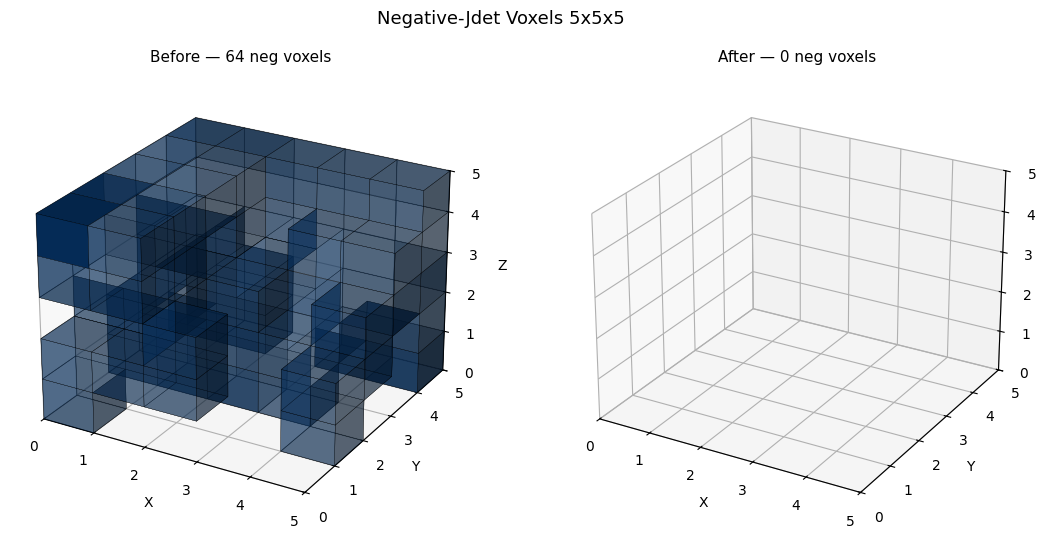

  [saved] ..\..\output\barrier\3d-correction\figure_02.png


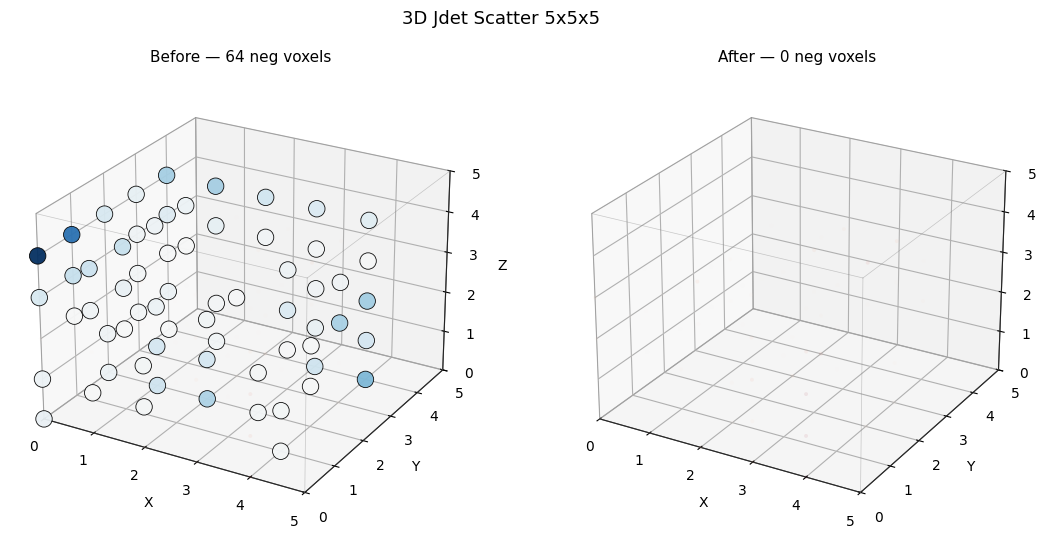

  [saved] ..\..\output\barrier\3d-correction\figure_03.png


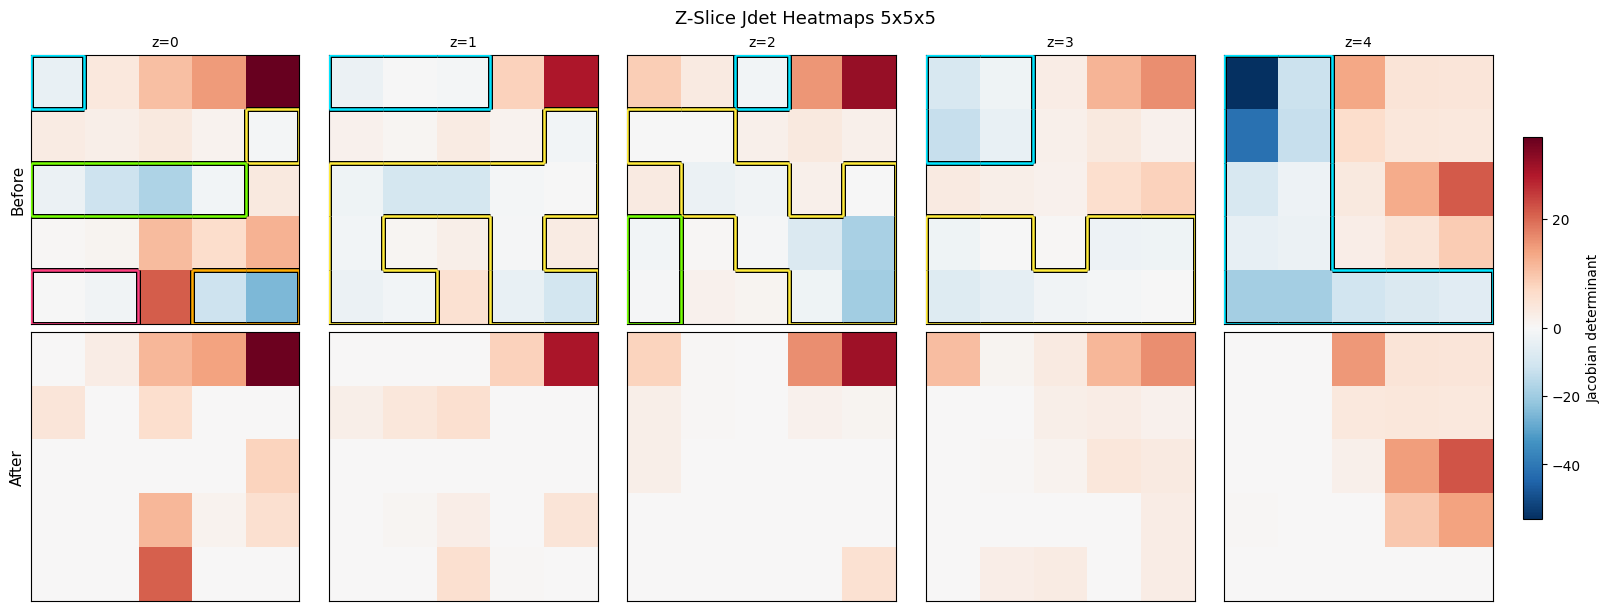

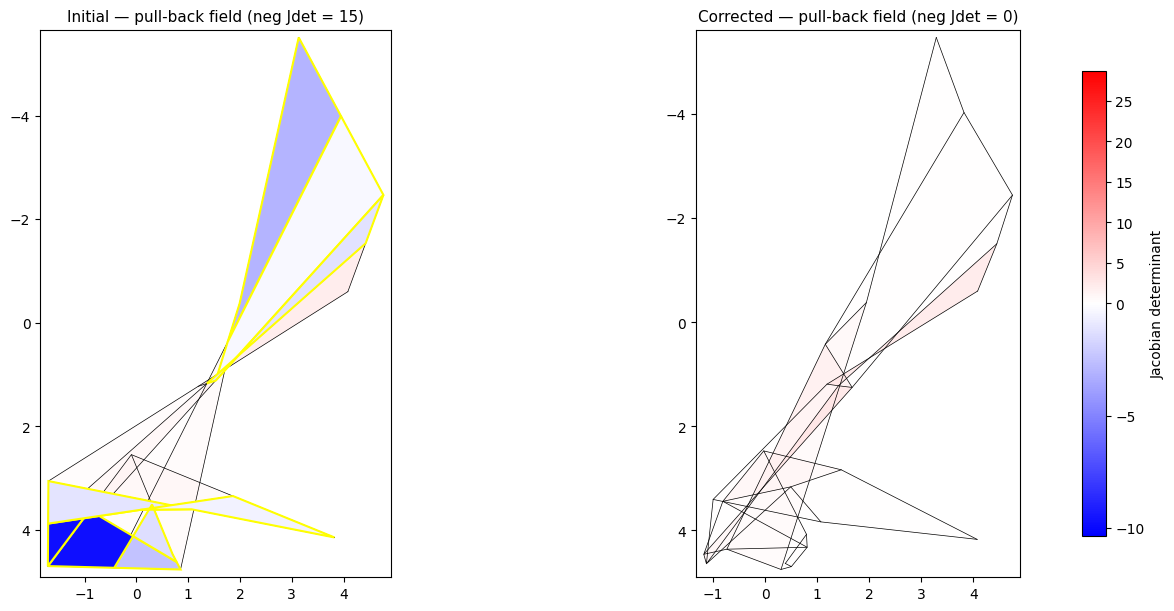

  [saved] ..\..\output\barrier\3d-correction\figure_04.png


<Figure size 640x480 with 0 Axes>

  [saved] ..\..\output\barrier\3d-correction\figure_05.png


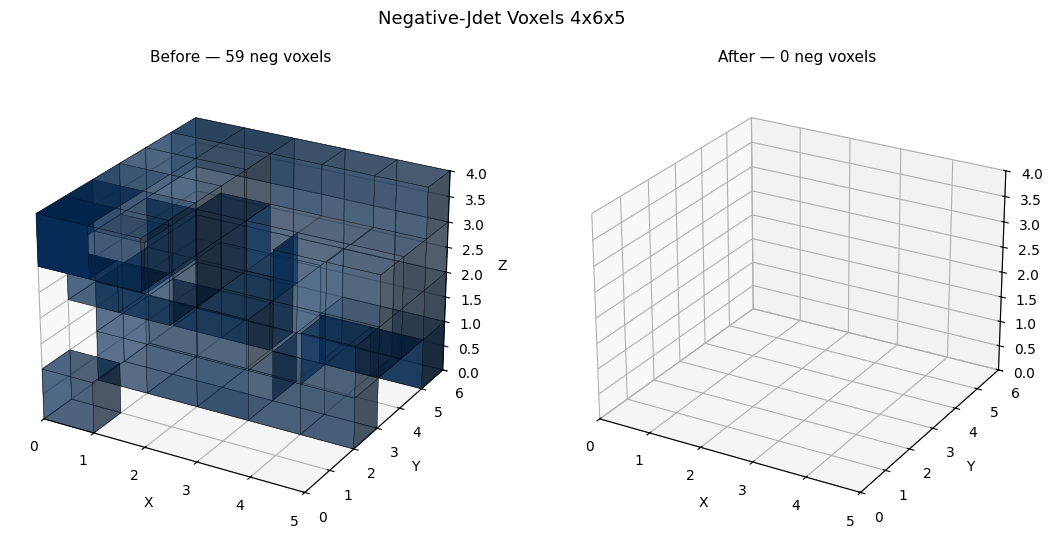

  [saved] ..\..\output\barrier\3d-correction\figure_06.png


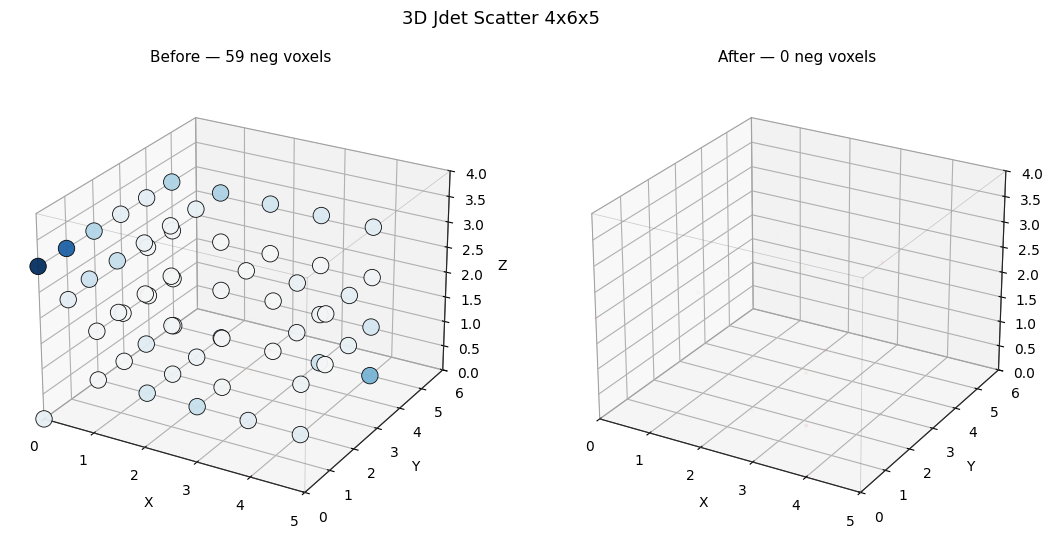

  [saved] ..\..\output\barrier\3d-correction\figure_07.png


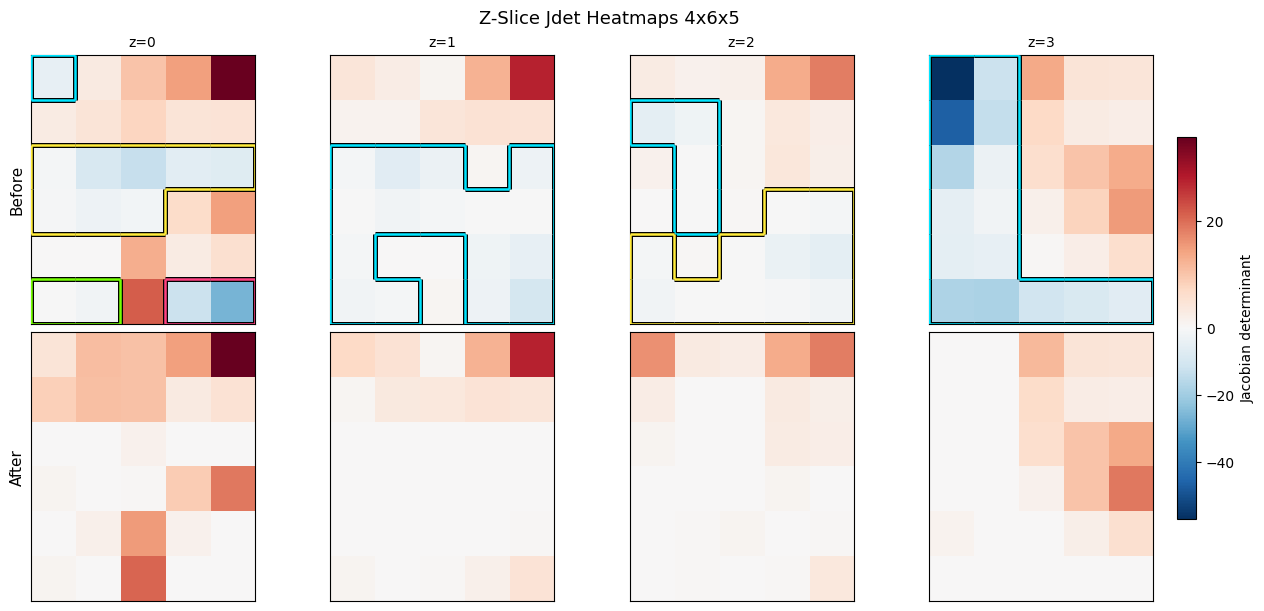

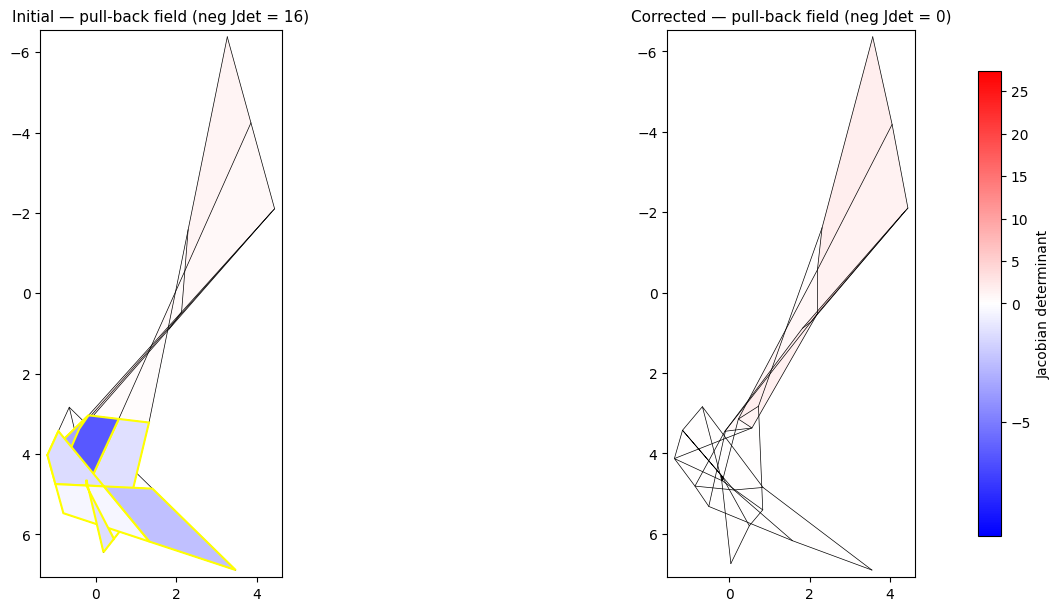

  [saved] ..\..\output\barrier\3d-correction\figure_08.png


<Figure size 640x480 with 0 Axes>

  [saved] ..\..\output\barrier\3d-correction\figure_09.png


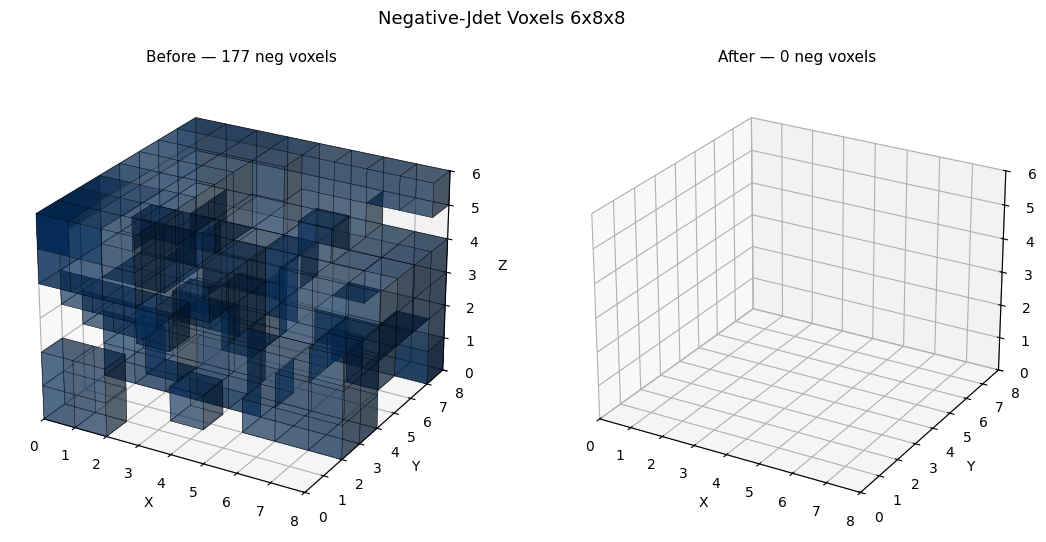

  [saved] ..\..\output\barrier\3d-correction\figure_10.png


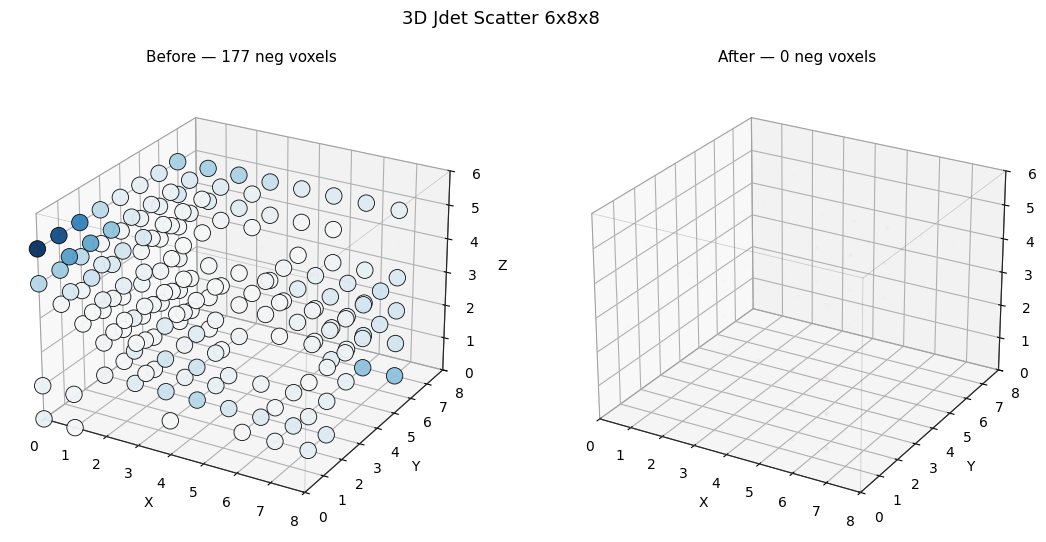

  [saved] ..\..\output\barrier\3d-correction\figure_11.png


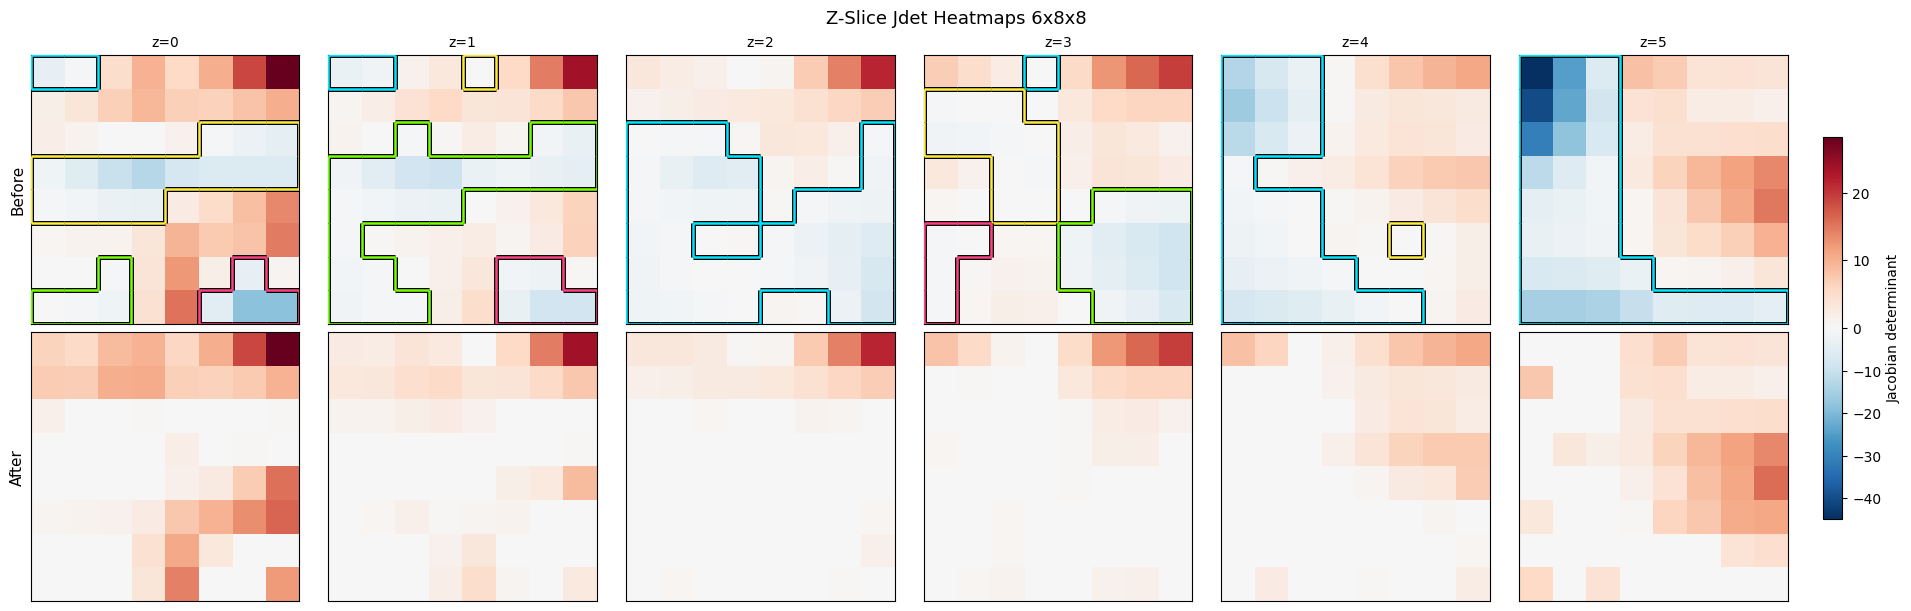

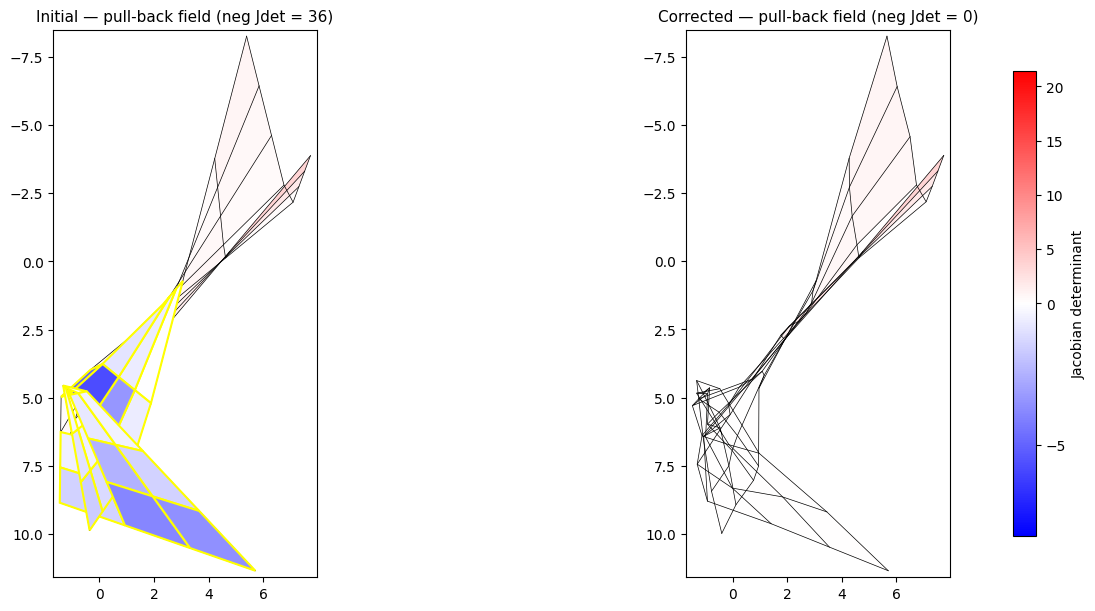

  [saved] ..\..\output\barrier\3d-correction\figure_12.png


<Figure size 640x480 with 0 Axes>

  [saved] ..\..\output\barrier\3d-correction\figure_13.png


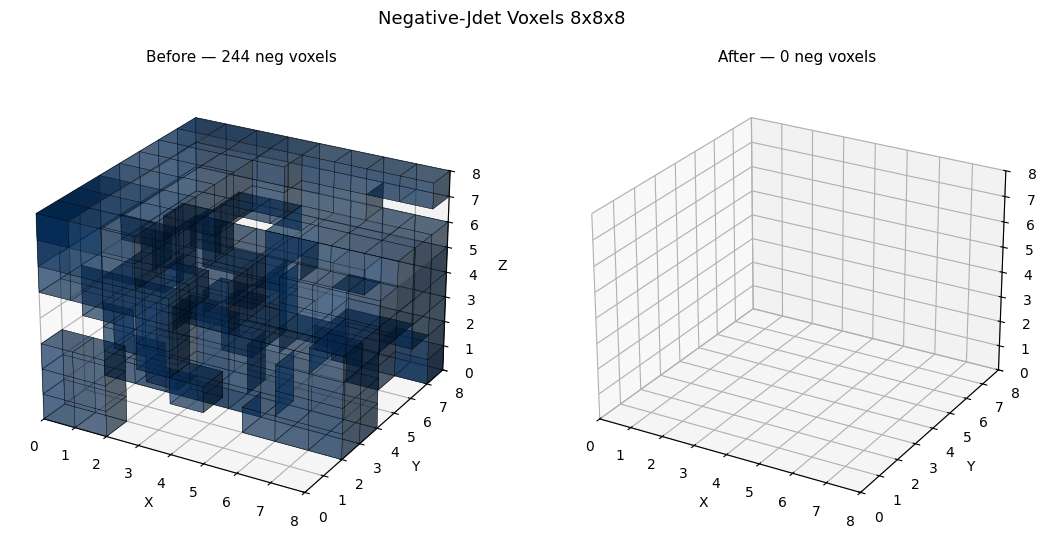

  [saved] ..\..\output\barrier\3d-correction\figure_14.png


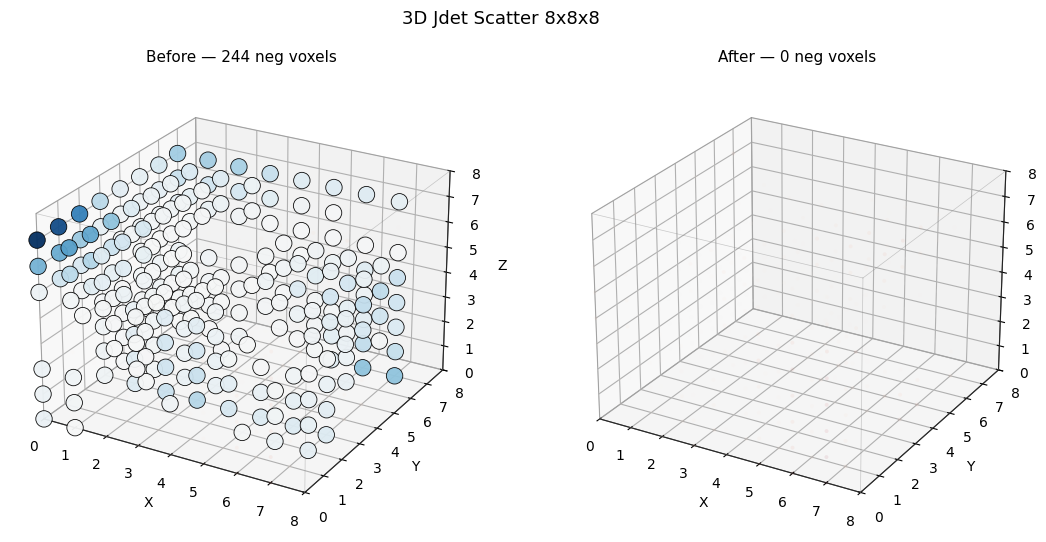

  [saved] ..\..\output\barrier\3d-correction\figure_15.png


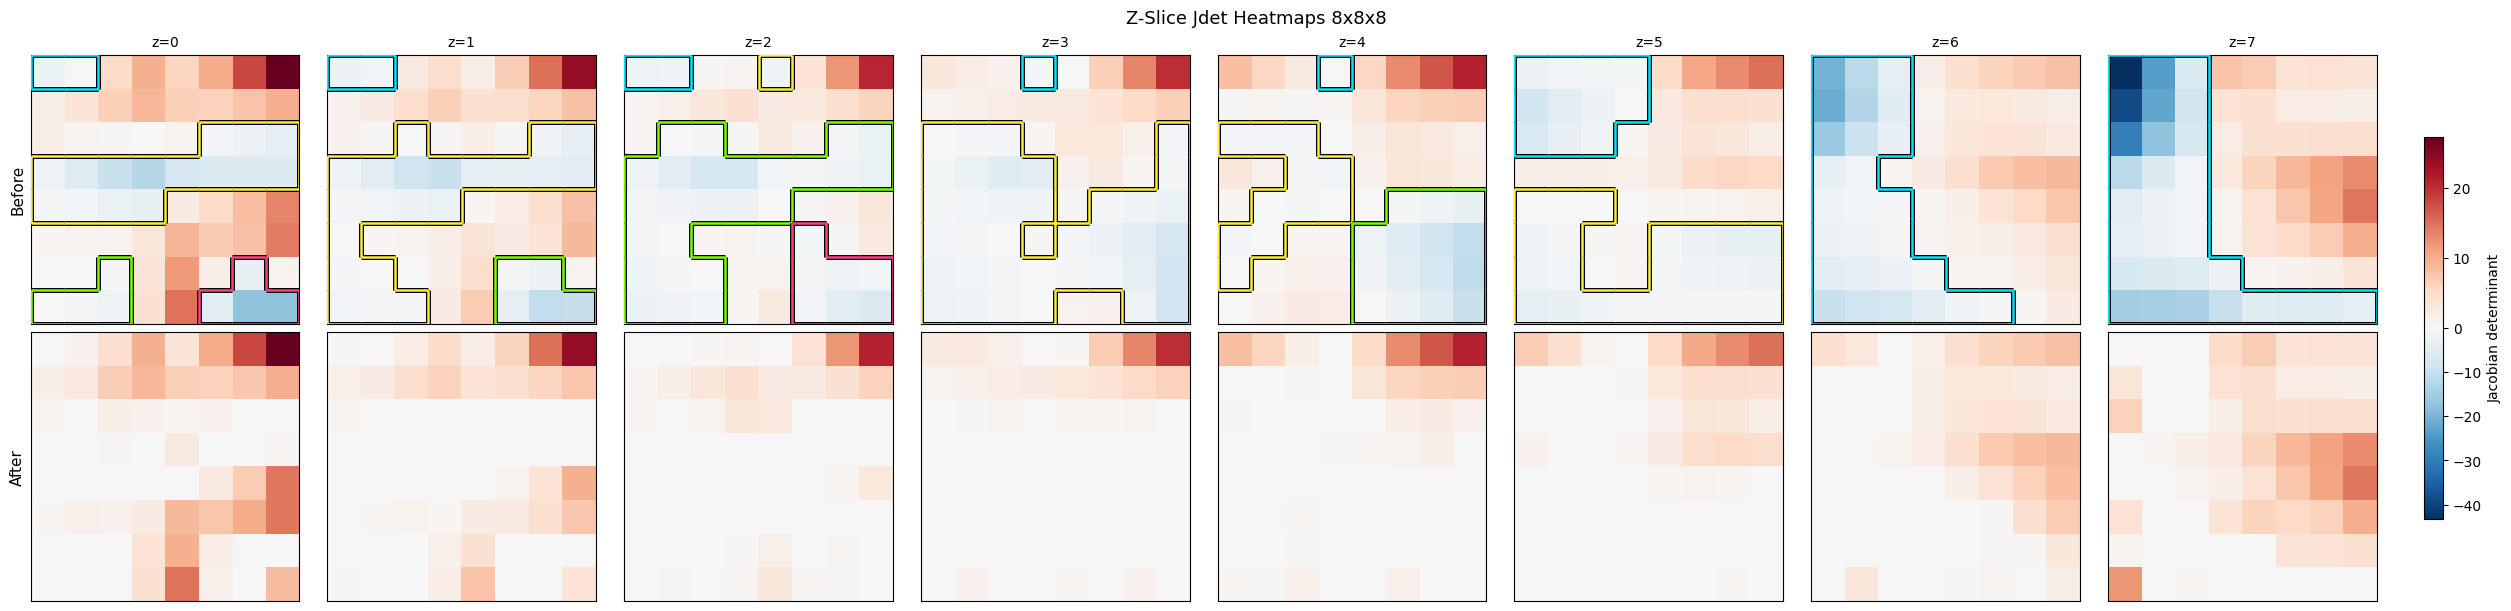

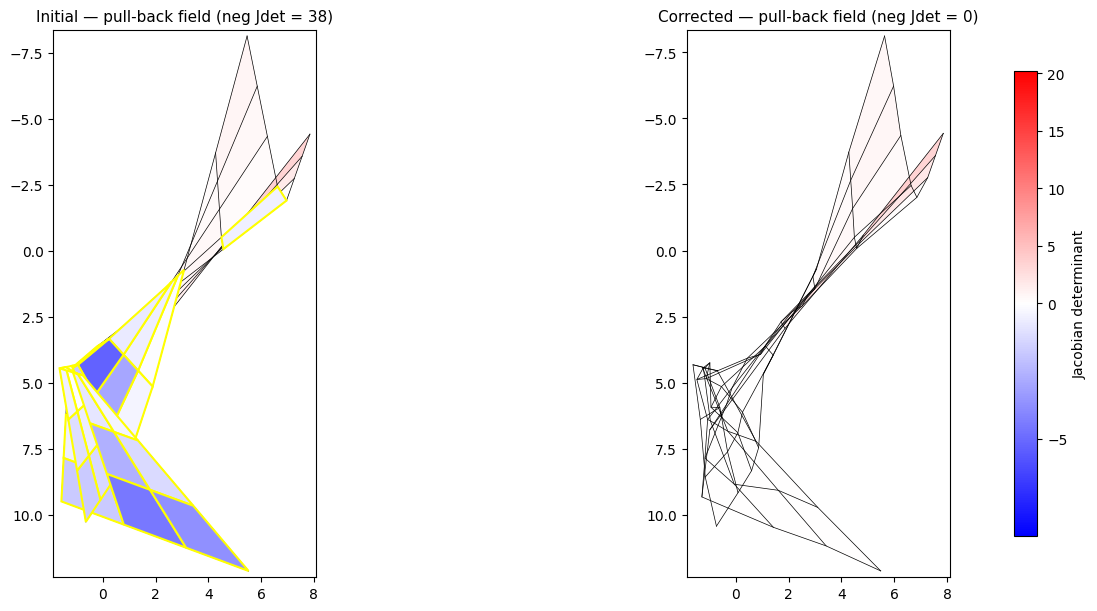

  [saved] ..\..\output\barrier\3d-correction\figure_16.png


<Figure size 640x480 with 0 Axes>

In [6]:
for _label in test_fields:
    if _label in results:
        visualize_result(_label, results[_label])


## Real volume - CPU at multiple downsample factors

Runs `iterative_3d_barrier` (CPU, windowed) on the real Elastix volume
at each factor in `DOWNSAMPLE_FACTORS`. Windowed mode keeps memory bounded
by the largest connected-component window, so the full-resolution
`(528, 320, 456)` volume is tractable on CPU.


In [ ]:
if os.path.exists(FULL_VOLUME_PATH):
    full_dvf = np.load(FULL_VOLUME_PATH)
    _, Df, Hf, Wf = full_dvf.shape
    print(f"Original full volume: {full_dvf.shape}", flush=True)

    print(f"{'Factor':>8s}  {'Shape':>18s}  {'Neg init':>10s}  {'Neg final':>10s}  {'Min Jdet':>12s}  {'L2':>10s}  {'Time (s)':>10s}")
    print("-" * 90)

    for factor in DOWNSAMPLE_FACTORS:
        print()
        print("=" * 90, flush=True)
        factor_label = {1/4: "1/4", 1/2: "1/2", 1: "1/1"}.get(factor, f"{factor:.3f}")
        print(f"  Downsample factor: {factor_label}", flush=True)
        print("=" * 90, flush=True)
        if factor == 1:
            ds_dvf = full_dvf.copy()
        else:
            new_shape = (
                max(1, round(Df * factor)),
                max(1, round(Hf * factor)),
                max(1, round(Wf * factor)),
            )
            ds_dvf = scale_dvf_3d(full_dvf, new_shape)

        shape_label = f"{ds_dvf.shape[1]}x{ds_dvf.shape[2]}x{ds_dvf.shape[3]}"
        label = f"Real {factor_label}"

        jac_init = jacobian_det3D(ds_dvf)
        init_neg = int((jac_init <= 0).sum())
        init_min = float(jac_init.min())

        print(f"[{factor_label}] Running iterative_3d_barrier on {shape_label} "
              f"(init neg={init_neg}, min={init_min:+.3f}) ...", flush=True)
        t0 = time.time()
        phi = iterative_3d_barrier(ds_dvf, verbose=1, max_minimize_iter=200)
        elapsed = time.time() - t0

        jac_final = jacobian_det3D(phi)
        n_neg_final = int((jac_final <= 0).sum())
        min_jdet_final = float(jac_final.min())
        l2_err = float(np.linalg.norm(phi - ds_dvf))

        results[label] = {
            "phi": phi, "phi_init": ds_dvf,
            "jac_init": jac_init, "jac_final": jac_final,
            "time": elapsed,
            "n_neg_init": init_neg, "n_neg_final": n_neg_final,
            "min_jdet_init": init_min, "min_jdet": min_jdet_final,
            "l2_err": l2_err,
        }
        status = "OK" if n_neg_final == 0 else "PARTIAL"
        print(f"{factor_label:>8s}  {shape_label:>18s}  {init_neg:>10d}  "
              f"{n_neg_final:>10d}  {min_jdet_final:>+12.6f}  {l2_err:>10.4f}  "
              f"{elapsed:>10.1f}  [{status}]", flush=True)

    del full_dvf
else:
    print(f"Full volume file not found: {FULL_VOLUME_PATH}")


Original full volume: (3, 528, 320, 456)
  Factor               Shape    Neg init   Neg final      Min Jdet          L2    Time (s)
------------------------------------------------------------------------------------------

  Downsample factor: 1/4
[1/4] Running iterative_3d_barrier on 132x80x114 (init neg=296, min=-11.202) ...
[init] Grid 132x80x114  threshold=0.01  margin=0.001  mode=windowed
[init] Neg-Jdet voxels: 296  min Jdet: -11.201836
[iter 1] comps=  34  lam_steps=292 mu_steps= 60  neg=    8  min_J=-0.401342  L2=10.1133  t=5.80s
[iter 2] comps=   2  lam_steps= 18 mu_steps=  4  neg=    5  min_J=-0.203755  L2=10.2941  t=0.36s
[iter 3] comps=   2  lam_steps= 18 mu_steps=  4  neg=    0  min_J=+0.010811  L2=10.4104  t=0.20s

  SUMMARY  (Penalty->Barrier L-BFGS-B - 3D (windowed))
------------------------------------------------------------
  Grid size        : 132 x 80 x 114
  Iterations       : 3
  Neg-Jdet    296 ->     0
  Min Jdet  -11.201836 -> +0.010811
  L2 error         : 1

### Real downsampled volume visualisations


In [ ]:
for factor_label in ["1/4", "1/2"]:
    key = f"Real {factor_label}"
    if key in results:
        visualize_result(key, results[key])


In [ ]:
# --- Save results ---
rows, cols = results_to_rows(results)
save_results_csv(rows, cols, OUTPUT_DIR)
summary = log_run_footer(summary, results)
save_summary_json(summary, OUTPUT_DIR)
